# Clasificacion de Calidad de Vino

## Paso 1: Cargar y exportacion Inicial del dataset
El dataset contiene analisis quimicos de vinos tintos, el objetivo es predecir si un vino es de **buena o mala calidad** basandonos en sus componentes.

In [14]:
import pandas as pd

In [15]:
df = pd.read_csv('WineQT.csv')
print("Tamaño de nuestro dataset de vino:", df.shape)

df.head()


Tamaño de nuestro dataset de vino: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [16]:
#Analisamos el tipo de cada columna
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [17]:
#Verificamoss si hay valores nulos
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [18]:
#Vemos las estadisticas de cada columna
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


------------------------------------------------------------------------------

## Paso 2: EDA (Análisis Exploratorio de Datos)
El EDA sirve para entender los datos antes de modelar.

Visualizamos la distribución de las variables para entender
tendencias, balanceo de clases y correlaciones.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\IPF_2026\AppData\Local\Temp\ipykernel_18536\3353879150.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='muted')


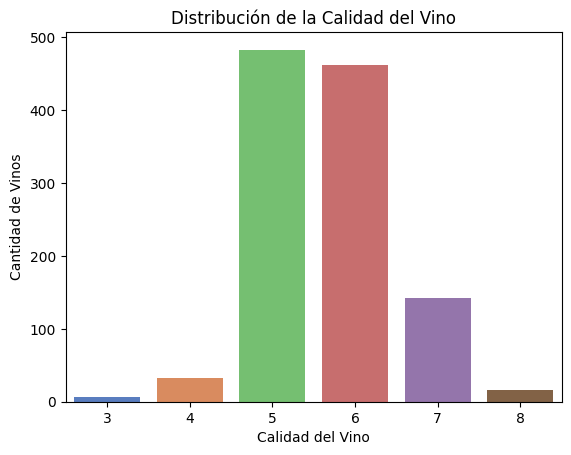

In [20]:
# Contamos cuantos vinos hay de cada calidad
sns.countplot(x='quality', data=df, palette='muted')
plt.title('Distribución de la Calidad del Vino')
plt.xlabel('Calidad del Vino')
plt.ylabel('Cantidad de Vinos')
plt.show()

Aqui podemos ver que la mayoria de vinos tienen una calidad de 5 y 6, muy pocos tienen 3 o 8, esto es importante porque muestra que el dataset esta **desbalanceado**, algo que se debe tener en cuenta en el modelo

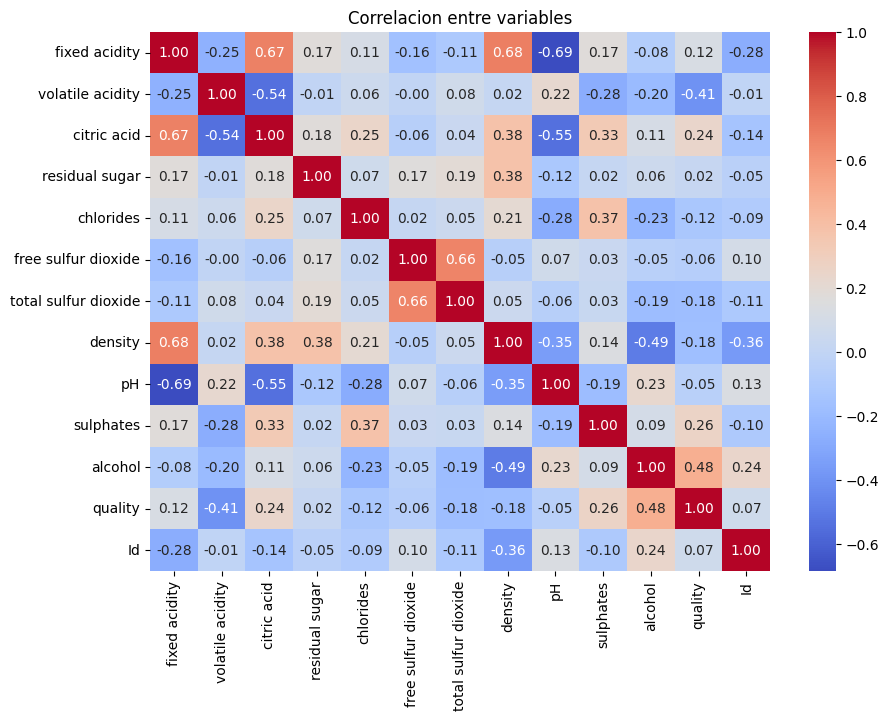

In [21]:
# Correlacion entre variables
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlacion entre variables')
plt.show()


Este grafico muestra que las variables más influyentes en la calidad son el alcohol (con una correlacion positiva de 0.48, nos quiere decir que mientras más aclohol más  calidad) y la acidez volatil (con una correlacion negativa de -0.41) estas variables van a ser importantes para el modelo

------------------------------------------------------------------------------

### Acidez volátil vs Calidad

C:\Users\IPF_2026\AppData\Local\Temp\ipykernel_18536\2156190888.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y= 'alcohol', data= df, palette='muted')


Text(0, 0.5, 'Alcohol (%)')

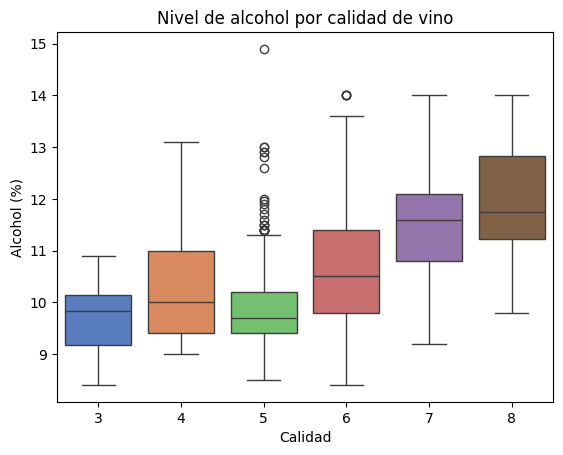

In [25]:
#ver como varia el alcohol segun la calidad
sns.boxplot(x='quality', y= 'alcohol', data= df, palette='muted')
plt.title('Nivel de alcohol por calidad de vino')
plt.xlabel('Calidad')
plt.ylabel('Alcohol (%)')

Podemos ver como los datos atipicos, vinos con alcohol muy alto para su calidad, de izquierda a derecha las cajas suben, los vinos de calidad 3 y 4 tienen medianas de alcohol de aprox 10%, mientras que los de calidad 7 y 8 estan entre 11 a 12%, nos confirma que **más alcohol = tendencia a mejor calidad.**

### Acidez volátil vs Calidad

C:\Users\IPF_2026\AppData\Local\Temp\ipykernel_18536\546921943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='volatile acidity', data=df, palette='muted')


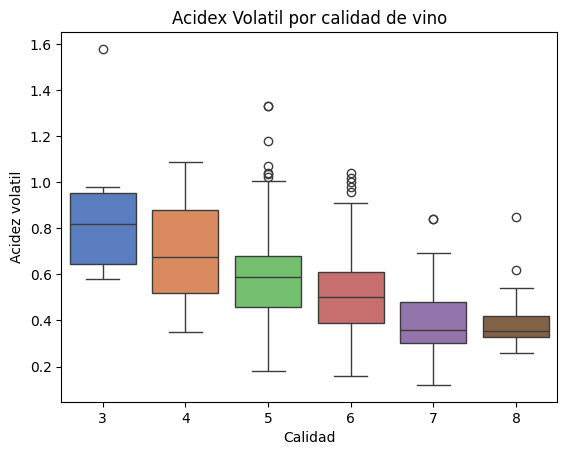

In [29]:
#La acidez volatil alta suele arruinar el vino
sns.boxplot(x='quality', y='volatile acidity', data=df, palette='muted')
plt.title('Acidex Volatil por calidad de vino')
plt.xlabel('Calidad')
plt.ylabel('Acidez volatil')
plt.show()

Aca podemos ver que la relacion es inversa, mientras mas acidez volatil el vino pierde calidad, ya que la acidez produce sabor a vinagre, por eso la calidad 3 es la que mas tiene.

### Distribucion de todas las variables

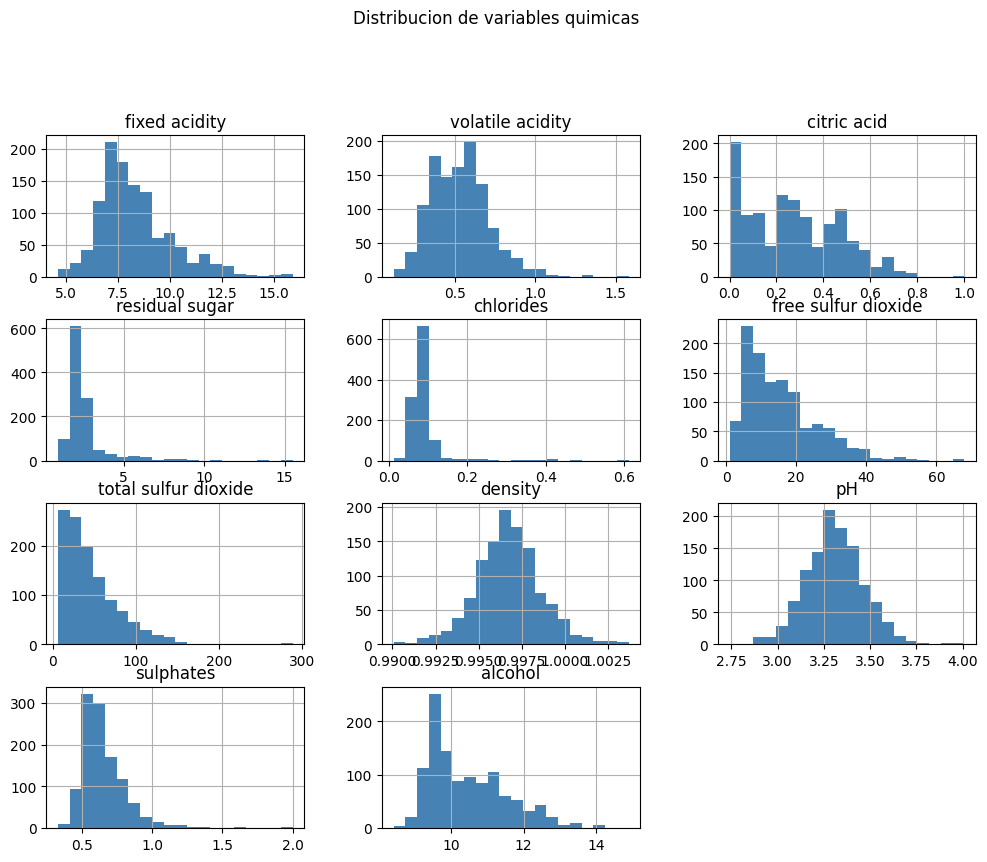

In [34]:
#Hacemos un histograma para todas las variables numericas
df.drop(columns=['Id', 'quality']).hist(figsize=(12,9), bins=20, color='steelblue')
plt.suptitle('Distribucion de variables quimicas', y=1.02)
plt.tight_layout
plt.show()

En este grafico podemos ver como se distribuyen cada variable quimica, en el eje x se muestra el valor de la variable y el eje y muestra cuantos vinos tienen ese valor, y tambien podemos ver que tienen escalas muy distintas entre cada variable y debemos aplicar la estandarizacion

Tenemos tres interpretaciones:

#### Las "Campanas":
Son aquellas que tinen forma de montaña o campana, esto quiere decir que la gran mayoria de los vinos tienen valores promedios (Ya que el pico esta en el centro) y hay muy pocos vinos con valores extremos (muy bajos o muy altos)
* Por ejemplo, el pH de ls vinos ronda mayoritariamente entre 3.25 y 3.4, es un dato estable y predecible

#### Los "Toboganes":
Toda la montaña esta empujada hacia la izquierda, con una "cola" larga que se arrastra hacia la derecha. La inmensa mayoria de los vinos tienen cantidades muy bajas de azucar residual (el pico esta al rededor de 2), sin embargo, hay pocos vinos que tienen el nivel de azucar alto que llegan a 15 aprox, son valores atipicos

### Caso Irregular:
Mirando Citric Acid no tiene ninguna de las formas que mencionamos, su pico mas alto es justamente en el 0.0, esto quiere decir que una gran cantidad de vinos en df simplemente no tienen acido citrico, y los demas no superan el 1.0